# Imports

In [1]:
import os
import json
import random

import cv2
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import torch
import torch.nn as nn
import torch.nn.functional as F

from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import (
    SequentialLR,
    LinearLR,
    CosineAnnealingLR,
)
from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
)

from config import CFG

# initalize transformers

In [2]:
def get_transforms(cfg):
    """
    Gibt (train_transform, val_transform) zurück.
    img_size und Augmentierungs-Parameter kommen aus CFG.
    """

    train_transform = A.Compose([
        # ── Geometrisch ───────────────────────────────────────────
        A.RandomResizedCrop(size=(cfg.img_size, cfg.img_size), scale=(0.8, 1.0)),
        A.HorizontalFlip(p=cfg.aug_p_flip),
        A.VerticalFlip(p=cfg.aug_p_flip),
        A.Affine(
            translate_percent = (-0.1, 0.1),
            scale             = (0.9, 1.1),
            rotate            = (-180, 180),
            p                 = 0.7
        ),

        # ── Farbe & Helligkeit ────────────────────────────────────
        A.OneOf([
            A.RandomBrightnessContrast(p=1.0),
            A.RandomGamma(p=1.0),
            A.HueSaturationValue(p=1.0),
        ], p=cfg.aug_p_color),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.4),

        # ── Rauschen & Unschärfe (Gerätevariation) ────────────────
        A.GaussNoise(noise_scale_factor=0.1, p=0.3),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),

        # ── Dermoskopie-spezifisch ────────────────────────────────
        A.CoarseDropout(
            p          = cfg.aug_p_cutout,
            num_holes_range=(1, 3),
            hole_height_range=(0.1, 0.2),
            hole_width_range=(0.1, 0.2),
        ),

        # ── Normalisierung & Tensor ───────────────────────────────
        A.Normalize(
            mean = [0.485, 0.456, 0.406],   # ImageNet-Werte
            std  = [0.229, 0.224, 0.225],
        ),
        ToTensorV2(),
    ])

    val_transform = A.Compose([
        A.Resize(cfg.img_size, cfg.img_size),
        A.Normalize(
            mean = [0.485, 0.456, 0.406],
            std  = [0.229, 0.224, 0.225],
        ),
        ToTensorV2(),
    ])

    return train_transform, val_transform


def get_tta_transforms(cfg):
    """
    Test-Time Augmentation: Liste von Transforms für Inferenz.
    Jedes Bild wird cfg.tta_steps mal unterschiedlich augmentiert,
    die Predictions werden gemittelt.
    """
    tta_list = []

    for _ in range(cfg.tta_steps):
        tta_list.append(A.Compose([
            A.Resize(cfg.img_size, cfg.img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Affine(rotate=(-45, 45), p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.Normalize(
                mean = [0.485, 0.456, 0.406],
                std  = [0.229, 0.224, 0.225],
            ),
            ToTensorV2(),
        ]))

    return tta_list

# normalize data

In [3]:
def prepare_metadata(df: pd.DataFrame, img_dir: str = None) -> tuple[pd.DataFrame, list[str]]:
    df = df.copy()

    # ── Alter ─────────────────────────────────────────────────────
    median_age     = df['age_approx'].median()
    df['age_norm'] = df['age_approx'].fillna(median_age) / 90.0

    # ── Geschlecht ────────────────────────────────────────────────
    df['sex_enc']  = df['sex'].map({'male': 1, 'female': 0}).fillna(0.5)

    # ── Körperstelle ──────────────────────────────────────────────
    site_dummies = pd.get_dummies(
        df['anatom_site_general_challenge'],
        prefix='site', dummy_na=True
    )
    df = pd.concat([df, site_dummies], axis=1)

    # ── n_images: Anzahl Bilder pro Patient ───────────────────────
    # Patienten mit vielen Bildern haben oft Verlaufsdokumentation
    df['n_images'] = df['patient_id'].map(
        df.groupby('patient_id')['image_name'].count()
    ).fillna(1)
    df['n_images'] = np.log1p(df['n_images'].values)  # log-skalieren: 1→0, 10→2.3, 100→4.6

    # ── image_size: Dateigrösse des Bildes ────────────────────────
    # Grössere Dateien = mehr Details = potenziell komplexere Läsion
    if img_dir is not None:
        sizes = []
        for name in df['image_name']:
            path = os.path.join(img_dir, f"{name}{CFG.img_ext}")
            sizes.append(os.path.getsize(path) if os.path.exists(path) else 0)
        df['image_size'] = np.log1p(sizes)   # log-skalieren
    else:
        df['image_size'] = 0.0               # Test-Set ohne Pfad: Nullwert

    # ── Meta-Spalten zusammenstellen ──────────────────────────────
    meta_cols = (
        ['age_norm', 'sex_enc', 'n_images', 'image_size']
        + [c for c in df.columns if c.startswith('site_')]
    )

    df[meta_cols] = df[meta_cols].fillna(0).astype('float32')
    return df, meta_cols

# Melanoma Data set

In [4]:
class MelanomaDataset(Dataset):
    def __init__(
        self,
        df:        pd.DataFrame,
        img_dir:   str,
        meta_cols: list[str],
        transform=None,
        is_test:   bool = False,
        img_ext:   str  = '.png',
    ):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.meta_cols = meta_cols
        self.transform = transform
        self.is_test   = is_test
        self.img_ext   = img_ext

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        # Bild laden (OpenCV → RGB)
        img_path = os.path.join(self.img_dir, f"{row['image_name']}{self.img_ext}")
        image    = cv2.imread(img_path)

        if image is None:
            # Raising an error if an image file is not found or cannot be read.
            # This helps identify data integrity issues early.
            raise FileNotFoundError(f"Bild nicht gefunden oder konnte nicht gelesen werden: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Albumentations erwartet numpy HWC uint8
        if self.transform:
            image = self.transform(image=image)['image']

        # Metadaten als Float-Tensor
        meta = torch.tensor(
            self.df.loc[idx, self.meta_cols].values.astype('float32')
        )

        if self.is_test:
            return image, meta

        label = torch.tensor(row['target'], dtype=torch.float32)
        return image, meta, label


# get loaders

In [5]:
def make_splits(df, cfg):
    sgkf = StratifiedGroupKFold(
        n_splits=cfg.n_folds,
        shuffle=True,
        random_state=cfg.seed
    )

    return list(
        sgkf.split(
            df,
            y=df["target"],
            groups=df["patient_id"]
        )
    )

def get_loaders(
    df:         pd.DataFrame,
    fold:       int,
    meta_cols:  list[str],
    cfg,
    train_tfm,
    val_tfm,
    splits=None,          # ← NEU: vorberechnete Splits akzeptieren
) -> tuple[DataLoader, DataLoader]:
    if splits is None:
        splits = make_splits(df, cfg)

    train_idx, val_idx = splits[fold]

    df_train = df.iloc[train_idx]
    df_val   = df.iloc[val_idx]

    train_ds = MelanomaDataset(
        df        = df_train,
        img_dir   = cfg.img_dir,
        meta_cols = meta_cols,
        transform = train_tfm,
        img_ext   = cfg.img_ext,
    )
    val_ds = MelanomaDataset(
        df        = df_val,
        img_dir   = cfg.img_dir,
        meta_cols = meta_cols,
        transform = val_tfm,
        img_ext   = cfg.img_ext,
    )

    labels   = df_train['target'].values
    class_w  = 1.0 / np.bincount(labels).astype(float)
    sample_w = torch.tensor(class_w[labels], dtype=torch.float32)

    sampler = WeightedRandomSampler(
        weights     = sample_w,
        num_samples = len(sample_w),
        replacement = True
    )

    train_loader = DataLoader(
        train_ds,
        batch_size  = cfg.batch_size,
        sampler     = sampler,
        num_workers = cfg.num_workers,
        pin_memory  = True,           
        drop_last   = True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size  = cfg.batch_size * 2,
        shuffle     = False,
        num_workers = cfg.num_workers,
        pin_memory  = True,          
    )

    return train_loader, val_loader

# Loader for test data

In [6]:
def get_test_loader(
    df:        pd.DataFrame,
    meta_cols: list[str],
    cfg,
    test_tfm,
) -> DataLoader:
    """Loader für Kaggle-Submission (kein Label, kein Sampler)."""
    test_ds = MelanomaDataset(
        df        = df,
        img_dir   = cfg.test_img_dir,
        meta_cols = meta_cols,
        transform = test_tfm,
        is_test   = True,
        img_ext   = cfg.img_ext,
    )
    return DataLoader(
        test_ds,
        batch_size  = cfg.batch_size * 2,
        shuffle     = False,
        num_workers = cfg.num_workers
    )

# Sample Run

In [7]:
df = pd.read_csv(CFG.train_csv)
df, meta_cols = prepare_metadata(df, img_dir=CFG.img_dir)

train_tfm, val_tfm = get_transforms(CFG)
train_loader, val_loader = get_loaders(df, fold=0, meta_cols=meta_cols,
                                       cfg=CFG, train_tfm=train_tfm,
                                       val_tfm=val_tfm)
df_test = pd.read_csv(CFG.test_csv)
df_test, _ = prepare_metadata(df_test, img_dir=CFG.test_img_dir)  # Meta-Cols müssen auch für Test-Set vorbereitet werden
test_loader = get_test_loader(df_test, meta_cols=meta_cols, cfg=CFG,
                              test_tfm=val_tfm)  # Test-Set bekommt gleiche Transforms wie Val

images, meta, labels = next(iter(train_loader))
print(f"images : {images.shape}")    # [32, 3, 384, 384]
print(f"meta   : {meta.shape}")      # [32, ~10]
print(f"labels : {labels.mean():.3f}")  # ~0.5 → Sampler funktioniert
print(f"n_meta : {len(meta_cols)}")
print(f"Fold 0 — Train: {len(train_loader.dataset):,} | Val: {len(val_loader.dataset):,}")
print(f"Test-Loader: {len(test_loader.dataset):,} Bilder")
print(f"Meta-Features ({len(meta_cols)}): {meta_cols}")

images : torch.Size([32, 3, 384, 384])
meta   : torch.Size([32, 11])
labels : 0.531
n_meta : 11
Fold 0 — Train: 26,499 | Val: 6,627
Test-Loader: 10,982 Bilder
Meta-Features (11): ['age_norm', 'sex_enc', 'n_images', 'image_size', 'site_head/neck', 'site_lower extremity', 'site_oral/genital', 'site_palms/soles', 'site_torso', 'site_upper extremity', 'site_nan']


In [8]:
df_test['image_name'][0]

'ISIC_0052060'

# Example Picture

In [9]:
def visualise_augmentation(image_id: str, cfg=CFG, transform=train_tfm):
    """
    Given an image ID (e.g. 'ISIC_0015719'), shows the original
    and augmented version side by side.
    """
    img_path = os.path.join(cfg.img_dir, f"{image_id}{cfg.img_ext}")
    image = cv2.imread(img_path)
    if image is None:
        raise FileNotFoundError(f"Image not found: {img_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Strip Normalize and ToTensorV2 so output stays as uint8 numpy [H,W,C]
    display_tfm = A.Compose([
        t for t in transform.transforms
        if not isinstance(t, (A.Normalize, ToTensorV2))
    ])

    augmented = display_tfm(image=image)['image']

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f"Image ID: {image_id}", fontsize=13, fontweight='bold')

    axes[0].imshow(image)
    axes[0].set_title('Original', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(augmented)
    axes[1].set_title('Augmented', fontsize=11)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

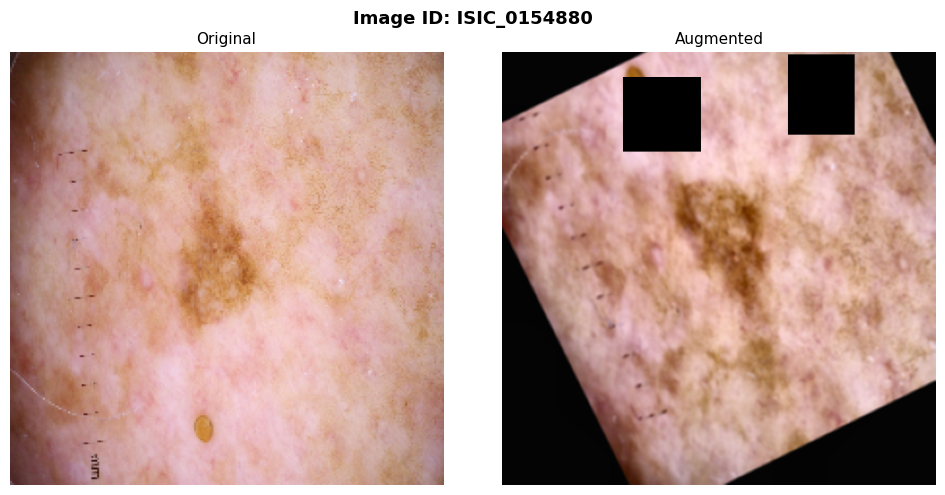

In [22]:
visualise_augmentation(df['image_name'][110])

# Melanoma Model

In [10]:
class GeM(nn.Module):
    """
    Generalized Mean Pooling — bessere Feature-Aggregation als AvgPool.
    p=1 = AvgPool, p→∞ = MaxPool, p=3 = optimaler Sweetspot für Texturen.
    p wird mittrainiert.
    """
    def __init__(self, p: float = 3.0, eps: float = 1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W) → (B, C)
        return F.adaptive_avg_pool2d(
            x.clamp(min=self.eps).pow(self.p),
            output_size=1
        ).pow(1.0 / self.p).squeeze(-1).squeeze(-1)


class MelanomaModel(nn.Module):
    def __init__(self, n_meta_features: int, cfg):
        super().__init__()

        # ── Bild-Branch: EfficientNet + GeM ───────────────────────
        self.backbone = timm.create_model(
            cfg.backbone,
            pretrained  = cfg.pretrained,
            num_classes = 0,
            global_pool = ''        # ← leer lassen: wir machen Pooling selbst
        )
        img_feat_dim = self.backbone.num_features  # 1792 für B4

        self.gem_pool = GeM(p=3.0)  # ← ersetzt global_pool='avg'

        # ── Metadaten-Branch: SiLU statt ReLU ─────────────────────
        self.meta_branch = nn.Sequential(
            nn.Linear(n_meta_features, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),              # ← Swish/SiLU statt ReLU
            nn.Dropout(p=0.3),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),              # ← Swish/SiLU statt ReLU
        )

        # ── Fusion Head: SiLU statt ReLU ──────────────────────────
        fused_dim = img_feat_dim + 256
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),              # ← Swish/SiLU statt ReLU
            nn.Dropout(p=cfg.dropout),
            nn.Linear(512, 1)
        )

    def forward(self, image: torch.Tensor, meta: torch.Tensor) -> torch.Tensor:
        feat  = self.backbone.forward_features(image)  # (B, C, H, W)
        feat  = self.gem_pool(feat)                    # (B, C) via GeM
        meta  = self.meta_branch(meta)                 # (B, 256)
        fused = torch.cat([feat, meta], dim=1)         # (B, C+256)
        return self.classifier(fused).squeeze(1)       # (B,)

In [11]:
# Schnellcheck
n_meta = len(meta_cols)
model  = MelanomaModel(n_meta_features=n_meta, cfg=CFG).to(CFG.device)
print(f"Backbone features : {model.backbone.num_features}")
print(f"Meta features     : {n_meta}")
print(f"Device            : {CFG.device}")

# Dummy Forward Pass
with torch.no_grad():
    dummy_img  = torch.randn(2, 3, CFG.img_size, CFG.img_size).to(CFG.device)
    dummy_meta = torch.randn(2, n_meta).to(CFG.device)
    out = model(dummy_img, dummy_meta)
    print(f"Output shape      : {out.shape}")   # torch.Size([2])
    print("Forward pass OK")

Backbone features : 2048
Meta features     : 11
Device            : cuda
Output shape      : torch.Size([2])
Forward pass OK


# Helper Functions

In [16]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

def focal_loss(logits, targets, alpha=0.25, gamma=2.0, smoothing=0.0):
    logits = torch.clamp(logits, min=-50, max=50)   # ← NEU
    targets = targets.float()
    if smoothing > 0:
        targets = targets * (1 - smoothing) + 0.5 * smoothing

    bce = nn.functional.binary_cross_entropy_with_logits(
        logits, targets, reduction="none"
    )

    probs = torch.sigmoid(logits)
    pt = probs * targets + (1 - probs) * (1 - targets)

    alpha_t = alpha * targets + (1 - alpha) * (1 - targets)

    loss = alpha_t * (1 - pt) ** gamma * bce
    return loss.mean()

def get_optimizer(model, cfg):
    """
    Optimizer für run_kfold.
    Ablation-Ergebnis: Uniform LR (AUC 0.8793) > Discriminative LR (AUC 0.8387).
    Steuerung über cfg.uniform_lr Flag.
    """
    if getattr(cfg, 'uniform_lr', False):
        # Uniform LR: alle Parameter gleiche Lernrate
        return torch.optim.AdamW(
            model.parameters(),
            lr=cfg.lr,
            weight_decay=cfg.weight_decay
        )
    else:
        # Discriminative LR: Backbone bekommt kleinere LR
        return torch.optim.AdamW([
            {'params': model.backbone.parameters(),   'lr': cfg.lr * cfg.backbone_lr_factor},
            {'params': model.gem_pool.parameters(),   'lr': cfg.lr * cfg.backbone_lr_factor},
            {'params': model.meta_branch.parameters(), 'lr': cfg.lr},
            {'params': model.classifier.parameters(),  'lr': cfg.lr},
        ], weight_decay=cfg.weight_decay)

def get_scheduler(optimizer, cfg):
    # Phase 1: Warmup — LR steigt linear von 10% auf 100% über warmup_epochs
    warmup = LinearLR(
        optimizer,
        start_factor = 0.1,          # startet bei lr * 0.1
        end_factor   = 1.0,
        total_iters  = cfg.warmup_epochs
    )
    # Phase 2: Cosine Decay — LR sinkt von 100% auf eta_min
    cosine = CosineAnnealingLR(
        optimizer,
        T_max   = cfg.epochs - cfg.warmup_epochs,
        eta_min = 1e-6
    )
    # Beide kombinieren: erst Warmup, dann Cosine
    return SequentialLR(
        optimizer,
        schedulers = [warmup, cosine],
        milestones = [cfg.warmup_epochs]
    )

def evaluate_oof(
    oof_labels,
    oof_preds,
    output_dir,
    threshold=0.5,
    filename="oof_metrics.json"
):
    os.makedirs(output_dir, exist_ok=True)

    oof_labels = np.asarray(oof_labels).astype(int)
    oof_preds = np.asarray(oof_preds).astype(float)

    y_pred = (oof_preds >= threshold).astype(int)

    roc_auc = roc_auc_score(oof_labels, oof_preds)
    pr_auc = average_precision_score(oof_labels, oof_preds)

    cm = confusion_matrix(oof_labels, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)

    metrics = {
        "threshold": float(threshold),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "accuracy": float(accuracy_score(oof_labels, y_pred)),
        "precision": float(precision_score(oof_labels, y_pred, zero_division=0)),
        "recall": float(recall_score(oof_labels, y_pred, zero_division=0)),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "f1": float(f1_score(oof_labels, y_pred, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

    metrics_path = os.path.join(output_dir, filename)

    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=4)

    print("\nOOF Evaluation")
    print("--------------------")
    print(f"ROC-AUC      : {metrics['roc_auc']:.4f}")
    print(f"PR-AUC       : {metrics['pr_auc']:.4f}")
    print(f"Accuracy     : {metrics['accuracy']:.4f}")
    print(f"Precision    : {metrics['precision']:.4f}")
    print(f"Recall/Sens. : {metrics['recall']:.4f}")
    print(f"Specificity  : {metrics['specificity']:.4f}")
    print(f"F1           : {metrics['f1']:.4f}")
    print(f"TP / FP / FN / TN: {tp} / {fp} / {fn} / {tn}")
    print(f"Saved metrics to: {metrics_path}")

def mixup_batch(images, labels, alpha=0.4):
    """Apply mixup to a batch. Returns mixed images and two label sets + lambda."""
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1 - lam) * images[idx]
    return mixed, labels, labels[idx], lam

def mixup_loss(logits, labels_a, labels_b, lam, cfg):
    loss_a = focal_loss(logits, labels_a, cfg.focal_alpha, cfg.focal_gamma, cfg.label_smoothing)
    loss_b = focal_loss(logits, labels_b, cfg.focal_alpha, cfg.focal_gamma, cfg.label_smoothing)
    return lam * loss_a + (1 - lam) * loss_b

seed_everything(CFG.seed)
print("Hilfsfunktionen bereit")

Hilfsfunktionen bereit


# Ablation testing

In [12]:
class MelanomaModelAblation(nn.Module):
    """
    Identische Architektur wie MelanomaModel (GeM + SiLU)
    aber mit use_meta Flag für Ablation Studies.
    """
    def __init__(self, n_meta_features: int, cfg, use_meta: bool = True):
        super().__init__()
        self.use_meta = use_meta

        # ── Backbone + GeM ────────────────────────────────────────
        self.backbone = timm.create_model(
            cfg.backbone,
            pretrained  = cfg.pretrained,
            num_classes = 0,
            global_pool = ''        # ← GeM übernimmt Pooling
        )
        img_feat_dim  = self.backbone.num_features
        self.gem_pool = GeM(p=3.0)  # ← gleich wie MelanomaModel

        # ── Meta-Branch (optional) ────────────────────────────────
        if use_meta and n_meta_features > 0:
            self.meta_branch = nn.Sequential(
                nn.Linear(n_meta_features, 256),
                nn.BatchNorm1d(256),
                nn.SiLU(),          # ← SiLU statt ReLU
                nn.Dropout(0.3),
                nn.Linear(256, 256),
                nn.BatchNorm1d(256),
                nn.SiLU(),          # ← SiLU statt ReLU
            )
            fused_dim = img_feat_dim + 256
        else:
            self.meta_branch = None
            fused_dim = img_feat_dim

        # ── Fusion Head ───────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),              # ← SiLU statt ReLU
            nn.Dropout(cfg.dropout),
            nn.Linear(512, 1)
        )

    def forward(self, image, meta=None):
        feat  = self.backbone.forward_features(image)   # (B, C, H, W)
        feat  = self.gem_pool(feat)                      # (B, C)
        if self.use_meta and meta is not None and self.meta_branch is not None:
            fused = torch.cat([feat, self.meta_branch(meta)], dim=1)
        else:
            fused = feat
        return self.classifier(fused).squeeze(1)

## Ablation run

In [15]:
# ── Ablation Study ────────────────────────────────────────────────────────────

ABLATION_EPOCHS = 8
ABLATION_FOLD   = 0

from sklearn.metrics import precision_recall_curve

def find_best_threshold(labels, preds):
    precisions, recalls, thresholds = precision_recall_curve(labels, preds)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    best_idx   = np.argmax(f1_scores)
    return thresholds[best_idx]

def get_scheduler_ablation(optimizer, cfg, epochs):
    warmup = LinearLR(optimizer, start_factor=0.1,
                      end_factor=1.0, total_iters=cfg.warmup_epochs)
    cosine = CosineAnnealingLR(optimizer,
                                T_max=epochs - cfg.warmup_epochs,
                                eta_min=1e-6)
    return SequentialLR(optimizer, schedulers=[warmup, cosine],
                        milestones=[cfg.warmup_epochs])

def get_current_lrs(optimizer):
    """
    Returns current learning rates for all optimizer parameter groups.
    """
    return [group["lr"] for group in optimizer.param_groups]


def get_optimizer_ablation(model, cfg, uniform_lr=False):
    """
    Eigener Optimizer für Ablation.
    Behandelt auch den Fall, dass meta_branch None ist.
    """

    if uniform_lr:
        return torch.optim.AdamW(
            model.parameters(),
            lr=cfg.lr,
            weight_decay=cfg.weight_decay
        )

    param_groups = [
        {
            "params": model.backbone.parameters(),
            "lr": cfg.lr * cfg.backbone_lr_factor,
            "name": "backbone"
        },
        {
            "params": model.gem_pool.parameters(),
            "lr": cfg.lr * cfg.backbone_lr_factor,
            "name": "gem_pool"
        },
        {
            "params": model.classifier.parameters(),
            "lr": cfg.lr,
            "name": "classifier"
        },
    ]

    if model.meta_branch is not None:
        param_groups.append({
            "params": model.meta_branch.parameters(),
            "lr": cfg.lr,
            "name": "meta_branch"
        })

    return torch.optim.AdamW(
        param_groups,
        weight_decay=cfg.weight_decay
    )


def compute_binary_metrics(labels, preds, threshold=None):
    labels = np.asarray(labels).astype(int)
    preds  = np.asarray(preds).astype(float)

    # Threshold automatisch optimieren wenn nicht angegeben
    if threshold is None:
        threshold = find_best_threshold(labels, preds)

    y_pred = (preds >= threshold).astype(int)

    auc     = roc_auc_score(labels, preds)
    pr_auc  = average_precision_score(labels, preds)
    tn, fp, fn, tp = confusion_matrix(labels, y_pred).ravel()

    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    precision   = precision_score(labels, y_pred, zero_division=0)
    recall      = recall_score(labels, y_pred, zero_division=0)
    f1          = f1_score(labels, y_pred, zero_division=0)
    accuracy    = accuracy_score(labels, y_pred)

    return {
        "auc":         float(auc),
        "pr_auc":      float(pr_auc),
        "threshold":   round(float(threshold), 4),
        "accuracy":    float(accuracy),
        "precision":   float(precision),
        "recall":      float(recall),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "f1":          float(f1),
        "tp": int(tp), "fp": int(fp),
        "fn": int(fn), "tn": int(tn),
    }


def compute_loss_from_name(logits, labels, cfg, loss_fn):
    """
    Selects loss function for ablation experiments.
    """

    if loss_fn == "focal":
        loss = focal_loss(
            logits,
            labels,
            alpha=cfg.focal_alpha,
            gamma=cfg.focal_gamma,
            smoothing=cfg.label_smoothing
        )

    elif loss_fn == "bce":
        loss = nn.functional.binary_cross_entropy_with_logits(
            logits,
            labels.float()
        )

    elif loss_fn == "bce_weighted":
        pos_weight = torch.tensor([50.0], device=cfg.device)
        loss = nn.functional.binary_cross_entropy_with_logits(
            logits,
            labels.float(),
            pos_weight=pos_weight
        )

    else:
        raise ValueError(f"Unknown loss_fn: {loss_fn}")

    return loss


def make_safe_experiment_name(exp_name):
    """
    Converts experiment name into safe folder name.
    """

    return (
        exp_name
        .lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("(", "")
        .replace(")", "")
        .replace(".", "")
        .replace("/", "_")
        .replace("ä", "ae")
        .replace("ö", "oe")
        .replace("ü", "ue")
    )


def run_single_experiment(
    exp_name,
    train_loader,
    val_loader,
    n_meta,
    cfg,
    use_meta=True,
    loss_fn="focal",
    uniform_lr=False,
):
    """
    Runs one ablation experiment on one fold.
    Saves:
    - epoch_logs.csv
    - best_val_predictions.csv
    """

    seed_everything(cfg.seed)

    safe_exp_name = make_safe_experiment_name(exp_name)
    exp_dir = os.path.join(cfg.output_dir, "ablations", safe_exp_name)
    os.makedirs(exp_dir, exist_ok=True)

    device_type = "cuda" if str(cfg.device).startswith("cuda") else "cpu"

    print("\n" + "-" * 60)
    print(f"Experiment : {exp_name}")
    print(f"Use meta   : {use_meta}")
    print(f"Loss       : {loss_fn}")
    print(f"Uniform LR : {uniform_lr}")
    print(f"Output dir : {exp_dir}")
    print("-" * 60)

    model = MelanomaModelAblation(
        n_meta_features=n_meta if use_meta else 0,
        cfg=cfg,
        use_meta=use_meta
    ).to(cfg.device)

    optimizer = get_optimizer_ablation(
        model,
        cfg,
        uniform_lr=uniform_lr
    )

    scheduler = get_scheduler_ablation(optimizer, cfg, ABLATION_EPOCHS)  # statt get_scheduler

    scaler = GradScaler(
        "cuda",
        enabled=cfg.use_amp
    )

    best_auc = -np.inf
    best_epoch = None
    best_preds = None
    best_labels = None
    best_metrics = None

    epoch_logs = []

    for epoch in range(ABLATION_EPOCHS):
        print(f"\nEpoch {epoch + 1}/{ABLATION_EPOCHS}")

        # ── Train ─────────────────────────────────────────────────
        model.train()

        train_loss_total = 0.0
        train_labels = []
        train_preds = []

        optimizer.zero_grad(set_to_none=True)

        for step, (images, meta, labels) in enumerate(train_loader):
            images = images.to(cfg.device, non_blocking=True)
            labels = labels.to(cfg.device, non_blocking=True)

            if use_meta:
                meta = meta.to(cfg.device, non_blocking=True)
            else:
                meta = None

            with autocast(device_type=device_type, enabled=cfg.use_amp):
                logits = model(images, meta)
                loss = compute_loss_from_name(
                    logits=logits,
                    labels=labels,
                    cfg=cfg,
                    loss_fn=loss_fn
                )

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

            train_loss_total += loss.item()

            train_labels.extend(
                labels.detach().cpu().numpy().reshape(-1)
            )

            train_preds.extend(
                torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            )

            if (step + 1) % cfg.log_interval == 0:
                print(
                    f"  Step {step + 1}/{len(train_loader)} "
                    f"| Loss: {loss.item():.4f} "
                    f"| GradNorm: {float(grad_norm):.4f}"
                )

        scheduler.step()

        train_loss = train_loss_total / len(train_loader)

        train_metrics = compute_binary_metrics(
            labels=train_labels,
            preds=train_preds
        )

        # ── Validate ──────────────────────────────────────────────
        model.eval()

        val_loss_total = 0.0
        val_labels = []
        val_preds = []

        with torch.no_grad():
            for images, meta, labels in val_loader:
                images = images.to(cfg.device, non_blocking=True)
                labels = labels.to(cfg.device, non_blocking=True)

                if use_meta:
                    meta = meta.to(cfg.device, non_blocking=True)
                else:
                    meta = None

                with autocast(device_type=device_type, enabled=cfg.use_amp):
                    logits = model(images, meta)
                    val_loss = compute_loss_from_name(
                        logits=logits,
                        labels=labels,
                        cfg=cfg,
                        loss_fn=loss_fn
                    )

                val_loss_total += val_loss.item()

                val_labels.extend(
                    labels.detach().cpu().numpy().reshape(-1)
                )

                val_preds.extend(
                    torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
                )

        val_loss = val_loss_total / len(val_loader)

        val_metrics = compute_binary_metrics(
            labels=val_labels,
            preds=val_preds
        )

        current_lrs = get_current_lrs(optimizer)

        epoch_log = {
            "experiment": exp_name,
            "epoch": epoch + 1,

            "train_loss": float(train_loss),
            "train_auc": train_metrics["auc"],
            "train_pr_auc": train_metrics["pr_auc"],
            "train_accuracy": train_metrics["accuracy"],
            "train_sensitivity": train_metrics["sensitivity"],
            "train_specificity": train_metrics["specificity"],
            "train_f1": train_metrics["f1"],

            "val_loss": float(val_loss),
            "val_auc": val_metrics["auc"],
            "val_pr_auc": val_metrics["pr_auc"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_sensitivity": val_metrics["sensitivity"],
            "val_specificity": val_metrics["specificity"],
            "val_f1": val_metrics["f1"],
            "val_tp": val_metrics["tp"],
            "val_fp": val_metrics["fp"],
            "val_fn": val_metrics["fn"],
            "val_tn": val_metrics["tn"],

            "lr_group_0": float(current_lrs[0]),
            "lr_group_last": float(current_lrs[-1]),
        }

        epoch_logs.append(epoch_log)

        print(
            f"  [{exp_name}] "
            f"Epoch {epoch + 1}/{ABLATION_EPOCHS} "
            f"| Train Loss: {train_loss:.4f} "
            f"| Train AUC: {train_metrics['auc']:.4f} "
            f"| Val Loss: {val_loss:.4f} "
            f"| Val AUC: {val_metrics['auc']:.4f} "
            f"| Val PR-AUC: {val_metrics['pr_auc']:.4f} "
            f"| Sens: {val_metrics['sensitivity']:.4f} "
            f"| Spec: {val_metrics['specificity']:.4f} "
            f"| F1: {val_metrics['f1']:.4f}"
        )

        if val_metrics["auc"] > best_auc:
            best_auc = val_metrics["auc"]
            best_epoch = epoch + 1
            best_preds = np.asarray(val_preds)
            best_labels = np.asarray(val_labels)
            best_metrics = val_metrics

            print(
                f"  ✓ New best epoch: {best_epoch} "
                f"| AUC: {best_auc:.4f} "
                f"| PR-AUC: {best_metrics['pr_auc']:.4f}"
            )

    # ── Save epoch logs ───────────────────────────────────────────
    epoch_logs_df = pd.DataFrame(epoch_logs)
    epoch_log_path = os.path.join(exp_dir, "epoch_logs.csv")
    epoch_logs_df.to_csv(epoch_log_path, index=False)

    # ── Save best validation predictions ─────────────────────────
    best_pred_df = pd.DataFrame({
        "target": best_labels.astype(int),
        "pred": best_preds.astype(float),
    })

    best_pred_path = os.path.join(exp_dir, "best_val_predictions.csv")
    best_pred_df.to_csv(best_pred_path, index=False)

    result = {
        "experiment": exp_name,
        "best_epoch": int(best_epoch),
        "best_auc": round(float(best_auc), 4),
        "best_pr_auc": round(float(best_metrics["pr_auc"]), 4),
        "threshold":   round(float(best_metrics["threshold"]), 4), 
        "accuracy": round(float(best_metrics["accuracy"]), 4),
        "sensitivity": round(float(best_metrics["sensitivity"]), 4),
        "specificity": round(float(best_metrics["specificity"]), 4),
        "precision": round(float(best_metrics["precision"]), 4),
        "recall": round(float(best_metrics["recall"]), 4),
        "f1": round(float(best_metrics["f1"]), 4),
        "tp": int(best_metrics["tp"]),
        "fp": int(best_metrics["fp"]),
        "fn": int(best_metrics["fn"]),
        "tn": int(best_metrics["tn"]),
        "epoch_log_path": epoch_log_path,
        "best_pred_path": best_pred_path,
    }

    print("\nBest result:")
    print(
        f"  AUC: {result['best_auc']:.4f} "
        f"| PR-AUC: {result['best_pr_auc']:.4f} "
        f"| Sens: {result['sensitivity']:.4f} "
        f"| Spec: {result['specificity']:.4f} "
        f"| F1: {result['f1']:.4f}"
    )

    print(f"  Epoch log saved to: {epoch_log_path}")
    print(f"  Best predictions saved to: {best_pred_path}")

    # ── Cleanup ───────────────────────────────────────────────────
    del model, optimizer, scheduler, scaler

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


def run_ablation_study(df, meta_cols, cfg):
    """
    Runs all ablation experiments on one selected fold.
    """

    print("Daten vorbereiten...")

    train_tfm, val_tfm = get_transforms(cfg)

    train_loader, val_loader = get_loaders(
        df=df,
        fold=ABLATION_FOLD,
        meta_cols=meta_cols,
        cfg=cfg,
        train_tfm=train_tfm,
        val_tfm=val_tfm
    )

    # Loader ohne WeightedSampler für separate Ablation
    splits = make_splits(df, cfg)
    train_idx, val_idx = splits[ABLATION_FOLD]

    df_train = df.iloc[train_idx].reset_index(drop=True)

    train_ds_no_sampler = MelanomaDataset(
        df=df_train,
        img_dir=cfg.img_dir,
        meta_cols=meta_cols,
        transform=train_tfm,
        img_ext=cfg.img_ext
    )
    generator = torch.Generator()
    generator.manual_seed(cfg.seed) 

    train_loader_no_sampler = DataLoader(
        train_ds_no_sampler,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=True,
        drop_last=True,
        generator = generator
    )

    n_meta = len(meta_cols)
    results = []

    experiments = [
        (
            "Nur Bild Baseline",
            dict(
                use_meta=False,
                loss_fn="focal",
                uniform_lr=False
            )
        ),
        (
            "Bild plus Metadaten voll",
            dict(
                use_meta=True,
                loss_fn="focal",
                uniform_lr=False
            )
        ),
        (
            "BCE plus pos_weight",
            dict(
                use_meta=True,
                loss_fn="bce_weighted",
                uniform_lr=False
            )
        ),
        (
            "Uniform LR kein Disc",
            dict(
                use_meta=True,
                loss_fn="focal",
                uniform_lr=True
            )
        ),
    ]

    for name, kwargs in experiments:
        print(f"\n{'=' * 60}")
        print(f"  EXP: {name}")
        print(f"{'=' * 60}")

        result = run_single_experiment(
            exp_name=name,
            train_loader=train_loader,
            val_loader=val_loader,
            n_meta=n_meta,
            cfg=cfg,
            **kwargs
        )

        results.append(result)

    # Experiment ohne WeightedSampler
    print(f"\n{'=' * 60}")
    print("  EXP: Kein WeightedSampler")
    print(f"{'=' * 60}")

    result = run_single_experiment(
        exp_name="Kein WeightedSampler",
        train_loader=train_loader_no_sampler,
        val_loader=val_loader,
        n_meta=n_meta,
        cfg=cfg,
        use_meta=True,
        loss_fn="focal",
        uniform_lr=False
    )

    results.append(result)

    # ── Ergebnisse ────────────────────────────────────────────────
    results_df = pd.DataFrame(results).sort_values(
        "best_auc",
        ascending=False
    )

    print(f"\n{'=' * 60}")
    print(f"ABLATION ERGEBNISSE Fold {ABLATION_FOLD}, {ABLATION_EPOCHS} Epochs")
    print(f"{'=' * 60}")

    display_cols = [
        "experiment",
        "best_epoch",
        "best_auc",
        "best_pr_auc",
        "threshold", 
        "sensitivity",
        "specificity",
        "precision",
        "f1",
        "tp",
        "fp",
        "fn",
        "tn",
    ]

    print(results_df[display_cols].to_string(index=False))

    os.makedirs(cfg.output_dir, exist_ok=True)

    csv_path = os.path.join(cfg.output_dir, "ablation_results.csv")
    json_path = os.path.join(cfg.output_dir, "ablation_results.json")

    results_df.to_csv(csv_path, index=False)

    with open(json_path, "w") as f:
        json.dump(results, f, indent=4)

    print(f"\nGespeichert:")
    print(f"  CSV : {csv_path}")
    print(f"  JSON: {json_path}")

    return results_df


# ── Ablation starten ─────────────────────────────────────────────────────────
ablation_df = run_ablation_study(
    df=df,
    meta_cols=meta_cols,
    cfg=CFG
)

ablation_df

Daten vorbereiten...

  EXP: Nur Bild Baseline

------------------------------------------------------------
Experiment : Nur Bild Baseline
Use meta   : False
Loss       : focal
Uniform LR : False
Output dir : /teamspace/studios/this_studio/outputs/ablations/nur_bild_baseline
------------------------------------------------------------



Epoch 1/8
  Step 50/414 | Loss: 0.0923 | GradNorm: 0.8718
  Step 100/414 | Loss: 0.0864 | GradNorm: 0.7952
  Step 150/414 | Loss: 0.0753 | GradNorm: 0.6721
  Step 200/414 | Loss: 0.0667 | GradNorm: 0.5796
  Step 250/414 | Loss: 0.0559 | GradNorm: 0.5557
  Step 300/414 | Loss: 0.0604 | GradNorm: 0.5471
  Step 350/414 | Loss: 0.0712 | GradNorm: 0.5858
  Step 400/414 | Loss: 0.0621 | GradNorm: 0.5588
  [Nur Bild Baseline] Epoch 1/8 | Train Loss: 0.0759 | Train AUC: 0.6766 | Val Loss: 0.0568 | Val AUC: 0.7285 | Val PR-AUC: 0.0432 | Sens: 0.2479 | Spec: 0.9296 | F1: 0.0960
  ✓ New best epoch: 1 | AUC: 0.7285 | PR-AUC: 0.0432

Epoch 2/8
  Step 50/414 | Loss: 0.0730 | GradNorm: 0.6640
  Step 100/414 | Loss: 0.0503 | GradNorm: 0.4634
  Step 150/414 | Loss: 0.0800 | GradNorm: 0.6912
  Step 200/414 | Loss: 0.0579 | GradNorm: 0.4439
  Step 250/414 | Loss: 0.0507 | GradNorm: 0.4894
  Step 300/414 | Loss: 0.0696 | GradNorm: 0.5429
  Step 350/414 | Loss: 0.0529 | GradNorm: 0.4388
  Step 400/414 | L

,experiment,best_epoch,best_auc,best_pr_auc,threshold,accuracy,sensitivity,specificity,precision,recall,f1,tp,fp,fn,tn,epoch_log_path,best_pred_path
3,Uniform LR kein Disc,6,0.8793,0.1517,0.5,0.9502,0.4274,0.9596,0.1597,0.4274,0.2326,50,263,67,6247,/teamspace/studios/this_studio/outputs/ablatio...,/teamspace/studios/this_studio/outputs/ablatio...
2,BCE plus pos_weight,8,0.8432,0.0953,0.5,0.5135,0.9487,0.5057,0.0333,0.9487,0.0644,111,3218,6,3292,/teamspace/studios/this_studio/outputs/ablatio...,/teamspace/studios/this_studio/outputs/ablatio...
0,Nur Bild Baseline,8,0.8407,0.1001,0.5,0.8966,0.4957,0.9038,0.0848,0.4957,0.1448,58,626,59,5884,/teamspace/studios/this_studio/outputs/ablatio...,/teamspace/studios/this_studio/outputs/ablatio...
1,Bild plus Metadaten voll,7,0.8387,0.1183,0.5,0.8956,0.4786,0.9031,0.0815,0.4786,0.1393,56,631,61,5879,/teamspace/studios/this_studio/outputs/ablatio...,/teamspace/studios/this_studio/outputs/ablatio...
4,Kein WeightedSampler,8,0.7968,0.0869,0.5,0.9823,0.0000,1.0000,0.0000,0.0000,0.0000,0,0,117,6510,/teamspace/studios/this_studio/outputs/ablatio...,/teamspace/studios/this_studio/outputs/ablatio...


# Training Loop

In [17]:
def train_one_epoch(model, loader, optimizer, scaler, cfg):
    model.train()
    total_loss = 0
    all_labels, all_preds = [], []
    nan_steps = 0

    device_type = "cuda" if str(cfg.device).startswith("cuda") else "cpu"

    for images, meta, labels in loader:
        images = images.to(cfg.device, non_blocking=True)
        meta   = meta.to(cfg.device, non_blocking=True)
        labels = labels.to(cfg.device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # ── Mixup (50% der Batches) ───────────────────────────────
        use_mixup = np.random.random() < 0.5
        if use_mixup:
            lam = float(np.random.beta(0.4, 0.4))
            lam = np.clip(lam, 0.1, 0.9)   # ← NEU: verhindert extreme lam-Werte
            idx = torch.randperm(images.size(0), device=images.device)
            images_mixed = lam * images + (1 - lam) * images[idx]
            labels_b     = labels[idx]
        else:
            images_mixed = images

        with autocast(device_type=device_type, enabled=cfg.use_amp):
            logits = model(images_mixed, meta)

            if use_mixup:
                loss = (
                    lam       * focal_loss(logits, labels,   cfg.focal_alpha, cfg.focal_gamma, cfg.label_smoothing) +
                    (1 - lam) * focal_loss(logits, labels_b, cfg.focal_alpha, cfg.focal_gamma, cfg.label_smoothing)
                )
            else:
                loss = focal_loss(logits, labels, cfg.focal_alpha, cfg.focal_gamma, cfg.label_smoothing)

        # ── NaN guard ────────────────────────────────────────────
        if not torch.isfinite(loss):
            nan_steps += 1
            optimizer.zero_grad(set_to_none=True)
            scaler.update()             # AMP-Scaler trotzdem updaten
            print(f"  ⚠ NaN/Inf loss skipped (total skipped: {nan_steps})")
            continue                    # ← step überspringen, nicht akkumulieren

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(torch.sigmoid(logits).detach().cpu().numpy())

    if len(all_labels) == 0:
        raise RuntimeError("All steps produced NaN loss — check focal_loss implementation.")

    auc = roc_auc_score(all_labels, all_preds)
    return total_loss / len(loader), auc


@torch.no_grad()
def validate(model, loader, cfg):
    model.eval()
    total_loss = 0
    all_labels, all_preds = [], []

    device_type = "cuda" if str(cfg.device).startswith("cuda") else "cpu"  # ← FIX

    for images, meta, labels in loader:
        images = images.to(cfg.device, non_blocking=True)
        meta   = meta.to(cfg.device, non_blocking=True)
        labels = labels.to(cfg.device, non_blocking=True)

        with autocast(device_type=device_type, enabled=cfg.use_amp):  # ← FIX
            logits = model(images, meta)
            loss   = focal_loss(
                logits, labels,
                alpha     = cfg.focal_alpha,
                gamma     = cfg.focal_gamma,
                smoothing = cfg.label_smoothing,
            )

        total_loss += loss.item()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(torch.sigmoid(logits).cpu().numpy())

    preds = np.array(all_preds)
    auc   = roc_auc_score(all_labels, preds)
    return total_loss / len(loader), auc, preds

In [18]:
def run_kfold(df, meta_cols, cfg, early_stopping_patience=4):  # ← patience param
    seed_everything(cfg.seed)
    os.makedirs(cfg.output_dir, exist_ok=True)

    fold_scores  = []
    fold_metrics = []

    train_tfm, val_tfm = get_transforms(cfg)

    oof_preds  = np.zeros(len(df), dtype=np.float32)
    oof_labels = df["target"].values.astype(int).copy()

    splits = make_splits(df, cfg)   # ← einmal berechnen, weitergeben

    if len(splits) != cfg.n_folds:
        raise ValueError(f"Expected {cfg.n_folds} folds, got {len(splits)}.")

    for fold in range(cfg.n_folds):
        print(f"\n{'=' * 50}")
        print(f"  FOLD {fold + 1} / {cfg.n_folds}")
        print(f"{'=' * 50}")

        train_idx, val_idx = splits[fold]

        train_loader, val_loader = get_loaders(
            df        = df,
            fold      = fold,
            meta_cols = meta_cols,
            cfg       = cfg,
            train_tfm = train_tfm,
            val_tfm   = val_tfm,
            splits    = splits,     # ← NEU: vorberechnete Splits übergeben
        )

        model     = MelanomaModel(len(meta_cols), cfg).to(cfg.device)
        optimizer = get_optimizer(model, cfg)
        scheduler = get_scheduler(optimizer, cfg)
        scaler    = GradScaler("cuda", enabled=cfg.use_amp)

        best_auc       = -np.inf
        best_val_loss  = None
        best_epoch     = None
        best_val_preds = None
        epochs_no_improve = 0          # ← NEU: early stopping counter

        best_path = os.path.join(cfg.output_dir, f"fold{fold}_best.pth")

        for epoch in range(cfg.epochs):
            print(f"\nEpoch {epoch + 1}/{cfg.epochs}")

            train_loss, train_auc = train_one_epoch(
                model=model, loader=train_loader,
                optimizer=optimizer, scaler=scaler, cfg=cfg,
            )
            val_loss, val_auc, val_preds = validate(
                model=model, loader=val_loader, cfg=cfg,
            )

            scheduler.step()

            print(f"  Train — Loss: {train_loss:.4f} | AUC: {train_auc:.4f}")
            print(f"  Val   — Loss: {val_loss:.4f}   | AUC: {val_auc:.4f}")

            if val_auc > best_auc:
                best_auc       = val_auc
                best_val_loss  = val_loss
                best_epoch     = epoch + 1
                best_val_preds = val_preds.copy()
                epochs_no_improve = 0    # ← reset

                torch.save(model.state_dict(), best_path)
                print(
                    f"  ✓ Neues bestes Modell gespeichert "
                    f"(Epoch: {best_epoch}, AUC: {best_auc:.4f})"
                )
            else:
                epochs_no_improve += 1   # ← NEU
                print(f"  No improvement ({epochs_no_improve}/{early_stopping_patience})")
                if epochs_no_improve >= early_stopping_patience:
                    print(f"  ⏹ Early stopping at epoch {epoch + 1}")
                    break                # ← NEU

        # ── Safety checks ─────────────────────────────────────────
        if best_val_preds is None:
            raise RuntimeError(f"No val predictions saved for fold {fold + 1}.")
        if len(best_val_preds) != len(val_idx):
            raise ValueError(
                f"Fold {fold + 1}: prediction length mismatch. "
                f"Got {len(best_val_preds)} for {len(val_idx)} samples."
            )
        if not os.path.exists(best_path):
            raise FileNotFoundError(f"Checkpoint missing: {best_path}")

        oof_preds[val_idx] = best_val_preds
        fold_scores.append(float(best_auc))
        fold_metrics.append({
            "fold":          fold,
            "best_epoch":    int(best_epoch),
            "best_val_auc":  float(best_auc),
            "best_val_loss": float(best_val_loss),
            "n_train":       int(len(train_idx)),
            "n_val":         int(len(val_idx)),
            "checkpoint":    best_path,
        })

        print(f"\nFold {fold + 1} — Bestes Val AUC: {best_auc:.4f}")

        del model, optimizer, scheduler, scaler
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ── Fold Metrics speichern ────────────────────────────────────
    fold_metrics_df   = pd.DataFrame(fold_metrics)
    fold_metrics_path = os.path.join(cfg.output_dir, "fold_metrics.csv")
    fold_metrics_df.to_csv(fold_metrics_path, index=False)

    overall_auc = roc_auc_score(oof_labels, oof_preds)

    oof_metrics = evaluate_oof(
        oof_labels  = oof_labels,
        oof_preds   = oof_preds,
        output_dir  = cfg.output_dir,
        threshold   = cfg.threshold,
        filename    = "oof_metrics.json",
    )

    oof_df = pd.DataFrame({
        "image_name": df["image_name"].values,
        "target":     oof_labels,
        "pred":       oof_preds,
    })
    if "patient_id" in df.columns:
        oof_df["patient_id"] = df["patient_id"].values

    oof_path = os.path.join(cfg.output_dir, "oof_predictions.csv")
    oof_df.to_csv(oof_path, index=False)

    print(f"\n{'=' * 50}")
    print("K-Fold Ergebnis:")
    for i, s in enumerate(fold_scores):
        print(f"  Fold {i + 1}: {s:.4f}")
    print(f"  Mean AUC : {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
    print(f"  OOF AUC  : {overall_auc:.4f}")
    print("\nSaved files:")
    print(f"  Fold metrics    : {fold_metrics_path}")
    print(f"  OOF metrics     : {os.path.join(cfg.output_dir, 'oof_metrics.json')}")
    print(f"  OOF predictions : {oof_path}")

    return fold_scores, oof_preds, fold_metrics_df, oof_metrics

In [19]:
fold_scores, oof_preds, fold_metrics_df, oof_metrics = run_kfold(df, meta_cols, CFG)


  FOLD 1 / 5



Epoch 1/15
  Train — Loss: 0.0737 | AUC: 0.7278
  Val   — Loss: 0.0430   | AUC: 0.8804
  ✓ Neues bestes Modell gespeichert (Epoch: 1, AUC: 0.8804)

Epoch 2/15
  Train — Loss: 0.0621 | AUC: 0.7740
  Val   — Loss: 0.0273   | AUC: 0.8777
  No improvement (1/4)

Epoch 3/15
  Train — Loss: 0.0542 | AUC: 0.8290
  Val   — Loss: 0.0300   | AUC: 0.8674
  No improvement (2/4)

Epoch 4/15
  Train — Loss: 0.0495 | AUC: 0.8405
  Val   — Loss: 0.0246   | AUC: 0.8771
  No improvement (3/4)

Epoch 5/15
  Train — Loss: 0.0454 | AUC: 0.8555
  Val   — Loss: 0.0285   | AUC: 0.8944
  ✓ Neues bestes Modell gespeichert (Epoch: 5, AUC: 0.8944)

Epoch 6/15
  Train — Loss: 0.0423 | AUC: 0.8805
  Val   — Loss: 0.0209   | AUC: 0.9011
  ✓ Neues bestes Modell gespeichert (Epoch: 6, AUC: 0.9011)

Epoch 7/15
  Train — Loss: 0.0381 | AUC: 0.8927
  Val   — Loss: 0.0205   | AUC: 0.8442
  No improvement (1/4)

Epoch 8/15
  Train — Loss: 0.0365 | AUC: 0.8976
  Val   — Loss: 0.0166   | AUC: 0.8803
  No improvement (2/4)



In [20]:
import time
start = time.time()
for i, (images, meta, labels) in enumerate(train_loader):
    if i == 10: break
print(f"{(time.time() - start):.1f}s for 10 batches")

3.6s for 10 batches


# Inference + TTA

In [21]:


@torch.no_grad()
def predict_with_tta(model, df_test, meta_cols, cfg, base_loader, tta_transforms=None):
    """
    Predicts test probabilities using base validation transform + optional TTA transforms.

    Returns
    -------
    preds : np.ndarray
        Mean predicted malignancy probabilities, shape = (n_test_samples,)
    """

    model.eval()

    device_type = "cuda" if str(cfg.device).startswith("cuda") else "cpu"
    tta_transforms = tta_transforms or []

    pred_sets = []

    # ── 1) Base predictions ───────────────────────────────────────
    base_preds = []

    for images, meta in base_loader:
        images = images.to(cfg.device, non_blocking=True)
        meta = meta.to(cfg.device, non_blocking=True)

        with autocast(device_type=device_type, enabled=cfg.use_amp):
            logits = model(images, meta)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        base_preds.append(probs)

    base_preds = np.concatenate(base_preds).reshape(-1)
    pred_sets.append(base_preds)

    # ── 2) TTA predictions ────────────────────────────────────────
    for i, tta_tfm in enumerate(tta_transforms, start=1):
        tta_loader = get_test_loader(df_test, meta_cols, cfg, tta_tfm)
        tta_preds = []

        for images, meta in tta_loader:
            images = images.to(cfg.device, non_blocking=True)
            meta = meta.to(cfg.device, non_blocking=True)

            with autocast(device_type=device_type, enabled=cfg.use_amp):
                logits = model(images, meta)

            probs = torch.sigmoid(logits).detach().cpu().numpy()
            tta_preds.append(probs)

        tta_preds = np.concatenate(tta_preds).reshape(-1)
        pred_sets.append(tta_preds)

    # ── 3) Average base + TTA predictions ─────────────────────────
    preds = np.mean(pred_sets, axis=0)

    if len(preds) != len(df_test):
        raise ValueError(
            f"Prediction length mismatch: got {len(preds)} predictions "
            f"for {len(df_test)} test samples."
        )

    return preds


def create_submission(df_test, meta_cols, cfg, use_rank_ensemble=False):
    """
    Creates submission.csv from fold models.

    Parameters
    ----------
    df_test : pd.DataFrame
        Test dataframe.
    meta_cols : list[str]
        Metadata columns used by the model.
    cfg : CFG
        Config object.
    use_rank_ensemble : bool
        If False, averages raw sigmoid probabilities.
        If True, averages percentile ranks per fold.
        Use False for probability interpretation.
        Use True only for AUC-focused Kaggle-style ranking.
    """

    tta_transforms = get_tta_transforms(cfg)

    all_fold_preds = []

    _, val_tfm = get_transforms(cfg)
    test_loader = get_test_loader(df_test, meta_cols, cfg, val_tfm)

    for fold in range(cfg.n_folds):
        print(f"Inferenz Fold {fold + 1}/{cfg.n_folds}...")

        checkpoint_path = os.path.join(cfg.output_dir, f"fold{fold}_best.pth")

        if not os.path.exists(checkpoint_path):
            raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

        model = MelanomaModel(len(meta_cols), cfg).to(cfg.device)

        state_dict = torch.load(checkpoint_path, map_location=cfg.device)
        model.load_state_dict(state_dict)
        model.eval()

        fold_preds = predict_with_tta(
            model=model,
            df_test=df_test,
            meta_cols=meta_cols,
            cfg=cfg,
            base_loader=test_loader,
            tta_transforms=tta_transforms
        )

        all_fold_preds.append(fold_preds)

        print(
            f"  Fold {fold + 1} prediction range: "
            f"[{fold_preds.min():.4f}, {fold_preds.max():.4f}]"
        )

        del model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    all_fold_preds = np.vstack(all_fold_preds)

    # ── Ensemble ──────────────────────────────────────────────────
    if use_rank_ensemble:
        ranked_preds = []

        for fold_idx, preds in enumerate(all_fold_preds):
            ranked = pd.Series(preds).rank(pct=True).values
            ranked_preds.append(ranked)

            print(
                f"  Fold {fold_idx + 1} — raw range: "
                f"[{preds.min():.4f}, {preds.max():.4f}] "
                f"→ ranked range: [{ranked.min():.4f}, {ranked.max():.4f}]"
            )

        final_preds = np.mean(ranked_preds, axis=0)

    else:
        final_preds = np.mean(all_fold_preds, axis=0)

    if len(final_preds) != len(df_test):
        raise ValueError(
            f"Final prediction length mismatch: got {len(final_preds)} predictions "
            f"for {len(df_test)} test samples."
        )

    sub = pd.DataFrame({
        "image_name": df_test["image_name"].values,
        "target": final_preds
    })

    sub_path = os.path.join(cfg.output_dir, "submission.csv")
    sub.to_csv(sub_path, index=False)

    print(f"\nSubmission gespeichert: {sub_path}")
    print(f"Prediction range: [{final_preds.min():.4f}, {final_preds.max():.4f}]")
    print(sub.head())

    return sub

In [ ]:
sub = create_submission(
    df_test=df_test,
    meta_cols=meta_cols,
    cfg=CFG,
    use_rank_ensemble=False
    )

Inferenz Fold 1/5...
  Fold 1 prediction range: [0.0561, 0.8384]
Inferenz Fold 2/5...
  Fold 2 prediction range: [0.0143, 0.7900]
Inferenz Fold 3/5...
  Fold 3 prediction range: [0.0460, 0.8579]
Inferenz Fold 4/5...
  Fold 4 prediction range: [0.0155, 0.7046]
Inferenz Fold 5/5...
